In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
climate_allocations = pd.read_csv("/content/CERF Climate Related Allocations.csv")
donor_allocations = pd.read_csv("/content/CERF Donor allocations.csv")
donor_contributions = pd.read_csv("/content/CERF Donor contributions.csv")
cbpf_contributions = pd.read_csv("/content/CBPF Contributions.csv")
cbpf_projects = pd.read_csv("/content/CBPF Projects.csv")

In [3]:
# Presentation settings
pd.options.display.float_format = "{:,.2f}".format

COLORS = {
    'normal': '#3498db',      # Professional blue
    'outlier': '#e74c3c',     # Alert red
    'efficient': '#2ecc71',   # Success green
    'warning': '#f39c12',     # Warning orange
    'neutral': '#95a5a6',     # Neutral gray
    'primary': '#1f77b4',     # Deep blue
    'secondary': '#ff7f0e',   # Warm orange
    'success': '#2ca02c',     # Success green
    'accent1': '#9467bd',     # Purple
    'accent2': '#17becf',     # Cyan
}

sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.linewidth': 1.2,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

In [4]:
# Prepare CBPF Projects
cbpf = cbpf_projects.copy()

# trip whitespace from all column names
cbpf.columns = cbpf.columns.str.strip()

def parse_currency(val) -> float:
    """Strip currency formatting and return float; return NaN for blanks/dashes."""
    if pd.isna(val):
        return np.nan
    cleaned = re.sub(r"[^\d.]", "", str(val).strip())
    return float(cleaned) if cleaned else np.nan

currency_cols = ["TotalDirectCost", "TotalSupportCost", "Budget"]
for col in currency_cols:
    if col in cbpf.columns:
        cbpf[col] = cbpf[col].apply(parse_currency)

# Numeric conversion
beneficiary_cols = [
    "Men", "Women", "Boys", "Girls",
    "IndirectBeneficiaries", "CatchmentPopulation"]

for col in beneficiary_cols:
    if col in cbpf.columns:
        cbpf[col] = pd.to_numeric(cbpf[col], errors="coerce")

present_direct = [c for c in ["Men", "Women", "Boys", "Girls"] if c in cbpf.columns]
cbpf["direct_beneficiaries"] = cbpf[present_direct].sum(axis=1, min_count=1)

if "IndirectBeneficiaries" in cbpf.columns:
    cbpf["total_beneficiaries"] = cbpf["direct_beneficiaries"] + cbpf["IndirectBeneficiaries"]
else:
    cbpf["total_beneficiaries"] = cbpf["direct_beneficiaries"]

# Beneficiary definitions
cbpf["direct_beneficiaries"] = cbpf[["Men", "Women", "Boys", "Girls"]].sum(axis=1, min_count=1)
cbpf["total_beneficiaries"] = (
    cbpf["direct_beneficiaries"] + cbpf["IndirectBeneficiaries"]
    if "IndirectBeneficiaries" in cbpf.columns else cbpf["direct_beneficiaries"]
)

# Choose denominator
DENOM = "direct"

if DENOM == "direct":
    cbpf["beneficiaries_used"] = cbpf["direct_beneficiaries"]
elif DENOM == "total":
    cbpf["beneficiaries_used"] = cbpf["total_beneficiaries"]
elif DENOM == "catchment":
    if "CatchmentPopulation" in cbpf.columns:
        cbpf["beneficiaries_used"] = cbpf["CatchmentPopulation"]
    else:
        print("CatchmentPopulation column not found — falling back to 'direct'.")
        cbpf["beneficiaries_used"] = cbpf["direct_beneficiaries"]
else:
    raise ValueError("DENOM must be one of: direct, total, catchment")

# Actual cost spent
cbpf["cost_spent"] = cbpf["TotalDirectCost"] + cbpf["TotalSupportCost"]

# Keep only rows with valid cost and beneficiary data
cbpf = cbpf[
    cbpf["cost_spent"].notna() &
    cbpf["beneficiaries_used"].notna() &
    (cbpf["cost_spent"] > 0) &
    (cbpf["beneficiaries_used"] > 0)
].copy()

cbpf["cost_per_beneficiary"] = cbpf["cost_spent"] / cbpf["beneficiaries_used"]
cbpf["log_cpb"]  = np.log10(cbpf["cost_per_beneficiary"])

# Clean summary table
summary_stats = cbpf[["cost_spent", "beneficiaries_used", "cost_per_beneficiary"]].describe().round(2)
print(summary_stats)

# Choose fair benchmarking group
candidate_group_cols = [
    "AllocationTypeCategory", "AllocationType",
    "PooledFundName", "OrganizationType"
]
GROUP_COL = next((c for c in candidate_group_cols if c in cbpf.columns), None)
print("Benchmarking within:", GROUP_COL if GROUP_COL else "GLOBAL (no grouping column found)")

# Outlier flagging (IQR on log scale)
def flag_outliers_iqr(g, col="log_cpb", k=1.5):
    """Flag outliers using IQR method on log scale."""
    q1 = g[col].quantile(0.25)
    q3 = g[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    g = g.copy()
    g["is_outlier"] = (g[col] < low) | (g[col] > high)
    return g

if GROUP_COL:
    try:
        cbpf_flagged = cbpf.groupby(GROUP_COL, group_keys=False).apply(
            flag_outliers_iqr, include_groups=False)
        # Re-attach the grouping column if it was dropped
        if GROUP_COL not in cbpf_flagged.columns:
            cbpf_flagged[GROUP_COL] = cbpf[GROUP_COL]
    except TypeError:
        # Older pandas that doesn't support include_groups kwarg
        cbpf_flagged = cbpf.groupby(GROUP_COL, group_keys=False).apply(flag_outliers_iqr)
else:
    cbpf_flagged = flag_outliers_iqr(cbpf)

outlier_rate = cbpf_flagged["is_outlier"].mean()
print(f"Outlier rate: {outlier_rate:.2%}  ({cbpf_flagged['is_outlier'].sum()} projects)")

         cost_spent  beneficiaries_used  cost_per_beneficiary
count      9,141.00            9,141.00              9,141.00
mean     579,128.31           52,097.25                602.07
std      759,022.63          301,076.01              8,024.12
min       24,085.00                1.00                  0.02
25%      248,900.91            6,500.00                 10.66
50%      399,574.77           16,320.00                 25.55
75%      654,066.78           40,000.00                 62.13
max   18,759,780.87       17,129,679.00            302,808.80
Benchmarking within: AllocationTypeCategory
Outlier rate: 3.56%  (77 projects)


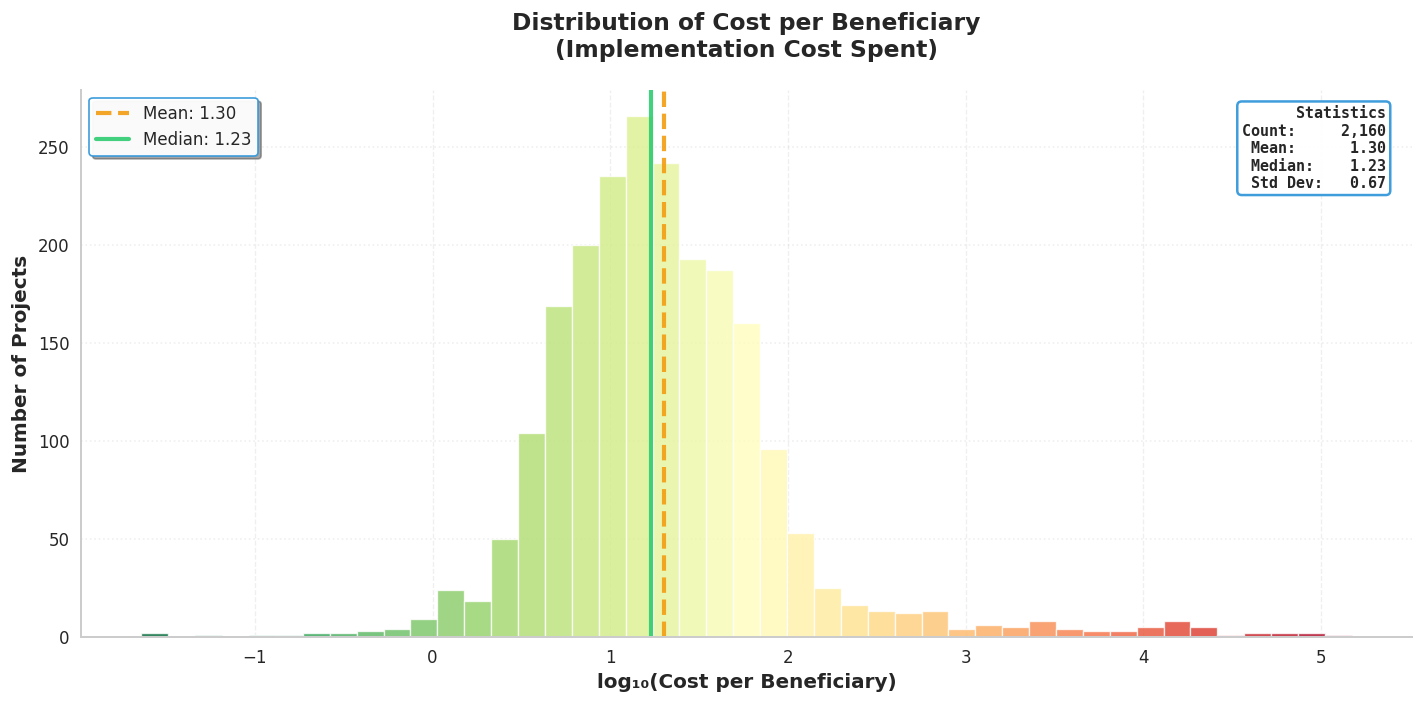

In [5]:
# Histogram
fig, ax = plt.subplots(figsize=(12, 6))

# Create histogram with gradient colors
n, bins, patches = ax.hist(cbpf_flagged["log_cpb"].dropna(),
                           bins=45,
                           color=COLORS['normal'],
                           edgecolor='white',
                           linewidth=0.8,
                           alpha=0.85)

# Apply color gradient to bars (Red-Yellow-Green)
cm = plt.cm.RdYlGn_r
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c), 'alpha', 0.8)

# Add statistical reference lines
mean_val = cbpf_flagged["log_cpb"].mean()
median_val = cbpf_flagged["log_cpb"].median()

ax.axvline(mean_val, color=COLORS['warning'], linestyle='--',
          linewidth=2.5, label=f'Mean: {mean_val:.2f}', alpha=0.9)
ax.axvline(median_val, color=COLORS['efficient'], linestyle='-',
          linewidth=2.5, label=f'Median: {median_val:.2f}', alpha=0.9)

# Add statistics box
stats_text = f"""Statistics
Count:     {len(cbpf_flagged['log_cpb'].dropna()):,}
Mean:      {mean_val:.2f}
Median:    {median_val:.2f}
Std Dev:   {cbpf_flagged['log_cpb'].std():.2f}"""

ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
       fontsize=9, verticalalignment='top', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.95,
                edgecolor=COLORS['normal'], linewidth=1.5),
       family='monospace', fontweight='bold')

# Professional styling
ax.set_xlabel('log₁₀(Cost per Beneficiary)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Projects', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Cost per Beneficiary\n(Implementation Cost Spent)',
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', framealpha=0.95, edgecolor=COLORS['normal'],
         fancybox=True, shadow=True, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

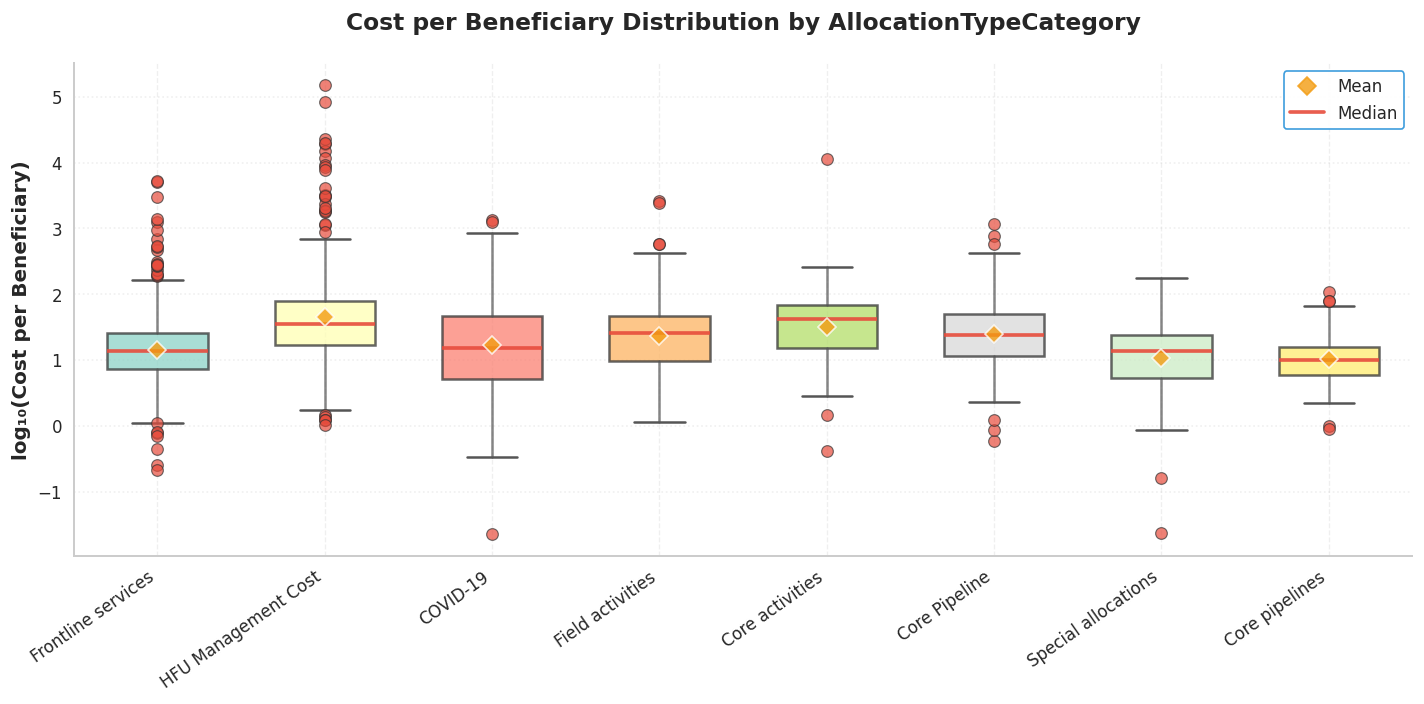

In [6]:
# Boxplot by top groups
if GROUP_COL:
    top_groups = cbpf_flagged[GROUP_COL].value_counts().head(8).index
    plot_df = cbpf_flagged[cbpf_flagged[GROUP_COL].isin(top_groups)]

    data = [plot_df.loc[plot_df[GROUP_COL] == g, "log_cpb"].dropna()
            for g in top_groups]
    labels = [str(g)[:25] for g in top_groups]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Create boxplot
    bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
                   showmeans=True,
                   meanprops=dict(marker='D', markerfacecolor=COLORS['warning'],
                                 markersize=8, alpha=0.8, markeredgecolor='white',
                                 markeredgewidth=1))

    # Apply color gradient to boxes
    colors_gradient = plt.cm.Set3(np.linspace(0, 1, len(top_groups)))
    for patch, color in zip(bp['boxes'], colors_gradient):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor('#333333')
        patch.set_linewidth(1.5)

    # Enhance whiskers, caps, and medians
    for whisker in bp['whiskers']:
        whisker.set(linewidth=1.5, color='#555555', alpha=0.7)
    for cap in bp['caps']:
        cap.set(linewidth=1.5, color='#555555')
    for median in bp['medians']:
        median.set(linewidth=2.2, color=COLORS['outlier'], alpha=0.9)
    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor=COLORS['outlier'], markersize=7,
                 alpha=0.7, markeredgecolor='#333333', markeredgewidth=0.7)

    # Professional styling
    ax.set_ylabel('log₁₀(Cost per Beneficiary)', fontsize=12, fontweight='bold')
    ax.set_title(f'Cost per Beneficiary Distribution by {GROUP_COL}',
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)
    ax.set_axisbelow(True)

    # Custom legend
    ax.plot([], [], 'D', color=COLORS['warning'], markersize=8, label='Mean', alpha=0.8)
    ax.plot([], [], '-', color=COLORS['outlier'], linewidth=2.2, label='Median', alpha=0.9)
    ax.legend(loc='upper right', framealpha=0.95, edgecolor=COLORS['normal'], fontsize=10)

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.xticks(rotation=35, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

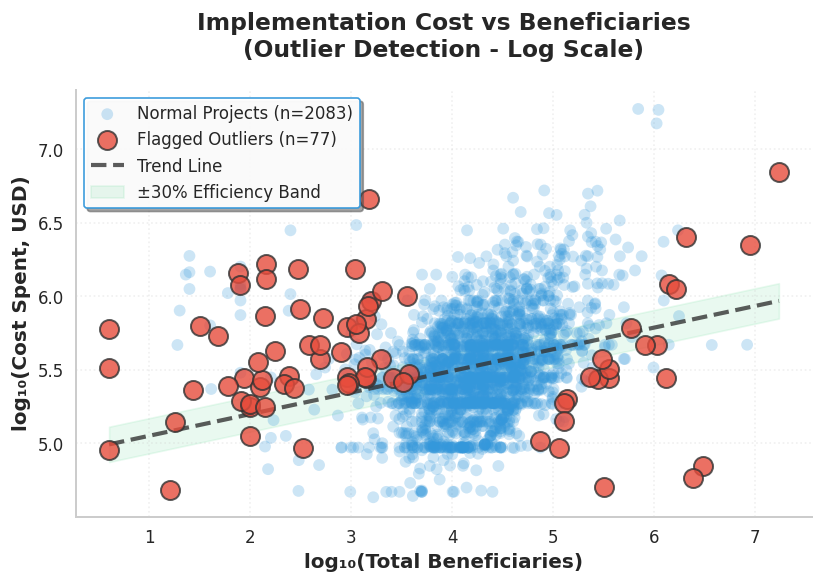

In [7]:
# Scatter-plot: Cost vs beneficiaries (outliers highlighted)
fig, ax = plt.subplots(figsize=(7, 5))

# Separate normal and outlier points
mask_outlier = cbpf_flagged["is_outlier"]
mask_normal = ~mask_outlier

# Plot normal projects (background)
ax.scatter(np.log10(cbpf_flagged.loc[mask_normal, "beneficiaries_used"]),
          np.log10(cbpf_flagged.loc[mask_normal, "cost_spent"]),
          s=50, alpha=0.25, color=COLORS['normal'],
          edgecolors='none', label=f'Normal Projects (n={mask_normal.sum()})',
          zorder=1)

# Plot flagged outliers (prominent)
ax.scatter(np.log10(cbpf_flagged.loc[mask_outlier, "beneficiaries_used"]),
          np.log10(cbpf_flagged.loc[mask_outlier, "cost_spent"]),
          s=130, alpha=0.8, color=COLORS['outlier'],
          edgecolors='#333333', linewidth=1.2,
          label=f'Flagged Outliers (n={mask_outlier.sum()})', zorder=3)

# Add trend line
z = np.polyfit(np.log10(cbpf_flagged['beneficiaries_used'].dropna()),
              np.log10(cbpf_flagged['cost_spent'].dropna()), 1)
p = np.poly1d(z)
x_line = np.linspace(np.log10(cbpf_flagged['beneficiaries_used'].min()),
                    np.log10(cbpf_flagged['beneficiaries_used'].max()), 100)
ax.plot(x_line, p(x_line), linestyle='--', color='#333333', linewidth=2.5,
       alpha=0.8, label='Trend Line', zorder=2)

# Add efficiency band (±30% from trend)
ax.fill_between(x_line, p(x_line) - 0.12, p(x_line) + 0.12,
               color=COLORS['efficient'], alpha=0.1, label='±30% Efficiency Band',
               zorder=0)

# Professional styling
ax.set_xlabel('log₁₀(Total Beneficiaries)', fontsize=12, fontweight='bold')
ax.set_ylabel('log₁₀(Cost Spent, USD)', fontsize=12, fontweight='bold')
ax.set_title('Implementation Cost vs Beneficiaries\n(Outlier Detection - Log Scale)',
            fontsize=14, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, linestyle=':', linewidth=1, which='both')
ax.legend(loc='upper left', framealpha=0.95, edgecolor=COLORS['normal'],
         fontsize=10, shadow=True)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# Flagged projects table (clean formatting)

# Define columns to display
cols_to_show = [c for c in [
    "ProjectTitle", "OrganizationName", "PooledFundName", GROUP_COL,
    "TotalDirectCost", "TotalSupportCost", "cost_spent",
    "beneficiaries_used", "cost_per_beneficiary",
    "ProjectStatus", "ProjectStartDate", "ProjectEndDate"
] if c in cbpf_flagged.columns]

# Identify and rank outliers by extremeness
flagged_projects = (
    cbpf_flagged[cbpf_flagged["is_outlier"]]
    .assign(extremeness=lambda d: abs(d["log_cpb"] - cbpf_flagged["log_cpb"].median()))
    .sort_values("extremeness", ascending=False)
    .head(20)[cols_to_show]
    .reset_index(drop=True)
)

# Rename columns for readability
pretty_flagged = flagged_projects.rename(columns={
    "ProjectTitle": "Project Title",
    "OrganizationName": "Organization",
    "PooledFundName": "Fund Name",
    GROUP_COL: "Cluster",
    "TotalDirectCost": "Direct Cost (USD)",
    "TotalSupportCost": "Support Cost (USD)",
    "cost_spent": "Cost Spent (USD)",
    "beneficiaries_used": "Beneficiaries",
    "cost_per_beneficiary": "Cost per Beneficiary (USD)",
    "ProjectStatus": "Status",
    "ProjectStartDate": "Start Date",
    "ProjectEndDate": "End Date"
})

# Apply styling
styled_flagged = (
    pretty_flagged.style
    .hide(axis="index")
    .set_caption("TOP 20 FLAGGED OUTLIER PROJECTS – RANKED BY EXTREMENESS")
    .set_table_styles([
        # caption
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px 0 6px 0"),
                ("color", "#1f4e79")
            ],
        },
        # overall table
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-family", "Arial, sans-serif"),
                ("font-size", "11px"),
                ("width", "100%")
            ],
        },
        # header
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f4e79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "7px 5px"),
                ("border-bottom", "2px solid #1f4e79"),
                ("word-wrap", "break-word")
            ],
        },
        # data cells
        {
            "selector": "td",
            "props": [
                ("padding", "6px 5px"),
                ("border-bottom", "1px solid #DDDDDD"),
                ("color", "black"),
                ("word-wrap", "break-word")
            ],
        },
    ])
    .format({
        "Direct Cost (USD)": "${:,.0f}",
        "Support Cost (USD)": "${:,.0f}",
        "Cost Spent (USD)": "${:,.0f}",
        "Beneficiaries": "{:,.0f}",
        "Cost per Beneficiary (USD)": "${:,.2f}",
    })
    # zebra striping for readability
    .apply(
        lambda s: [
            "background-color: #f0f5fa" if i % 2 == 0 else "background-color: white"
            for i in range(len(s))
        ],
        axis=0
    )
    # highlight cost_per_beneficiary column in orange (warning color)
    .background_gradient(
        subset=["Cost per Beneficiary (USD)"],
        cmap="Oranges",
        vmin=pretty_flagged["Cost per Beneficiary (USD)"].min(),
        vmax=pretty_flagged["Cost per Beneficiary (USD)"].max()
    )
    # left align text columns
    .set_properties(
        subset=[
            "Project Title",
            "Organization",
            "Fund Name",
            "Cluster",
            "Status",
            "Start Date",
            "End Date"
        ],
        **{"text-align": "left"}
    )
    # right align numeric columns
    .set_properties(
        subset=[
            "Direct Cost (USD)",
            "Support Cost (USD)",
            "Cost Spent (USD)",
            "Beneficiaries",
            "Cost per Beneficiary (USD)"
        ],
        **{"text-align": "right"}
    )
    # make project title column stand out slightly
    .applymap(
        lambda v: "font-weight: 600; color: #1f4e79;" if v else "",
        subset=["Project Title"]
    )
)

display(styled_flagged)

print(f"\nTotal flagged outliers: {len(cbpf_flagged[cbpf_flagged['is_outlier']])}")
print(f"Median Cost per Beneficiary (all data): ${cbpf_flagged['cost_per_beneficiary'].median():,.2f}")
print(f"Median Cost per Beneficiary (flagged): ${flagged_projects['cost_per_beneficiary'].median():,.2f}")


Project Title,Organization,Fund Name,Cluster,Direct Cost (USD),Support Cost (USD),Cost Spent (USD),Beneficiaries,Cost per Beneficiary (USD),Status,Start Date,End Date
Amélioration de la réponse humanitaire en santé et en nutrition par la création d'une plateforme de stockage dédiée en République Centrafricaine,Première Urgence Internationale,CAR,HFU Management Cost,"$461,749","$134,046","$595,794",4,"$148,948.60",Projet clôturé,01-12-18,31-08-19
"Intervention d’urgence de facilitation de l’accès humanitaire dans les territoires de Beni, Walikale, Lubero et Masisi au Nord-Kivu.",Federation Handicap International. Direction Aide Humanitaire,DRC,HFU Management Cost,"$227,962","$99,141","$327,103",4,"$81,775.70",Projet Clôturé,01-05-18,31-10-18
Renforcement de la Coordination Sectorielle WASH au travers la Co-facilitation du Cluster National WASH,Action Contre la Faim,CAR,HFU Management Cost,"$82,642","$7,078","$89,720",4,"$22,429.91",Projet clôturé,01-11-19,30-06-20
ETC Preparedness: IT and telecommunication services for emergency operations across Yemen (WFP),World Food Programme,Yemen,HFU Management Cost,"$604,131","$22,839","$626,970",32,"$19,592.80",Project Closed,01-07-18,31-12-18
Afghanistan CHF - 2014 Humanitarian Financing Unit (HFU) Proposal,United Nations Office for the Coordination of Humanitarian Affairs,Afghanistan,HFU Management Cost,"$1,259,088","$176,420","$1,435,508",75,"$19,140.11",Project Closed,01-01-14,31-12-14
2016 Afghanistan Humanitarian Fund - Humanitarian Financing Unit (HFU),United Nations Office for the Coordination of Humanitarian Affairs,Afghanistan,HFU Management Cost,"$1,156,880","$30,519","$1,187,399",80,"$14,842.49",Project Closed,01-01-16,31-12-16
Rapid response for the West Bank health-care waste management in response to COVID-19 outbreak,CESVI,oPt,COVID-19,"$65,364","$4,730","$70,094","3,043,316",$0.02,Project Closed,12-04-20,11-07-20
Monitoring and reporting support for Protection Sector humanitarian pooled fund allocations in Sudan,United Nations High Commissioner for Refugees,Sudan,Special allocations,"$57,074","$1,205","$58,279","2,440,110",$0.02,Under Closure,01-05-17,31-12-17
Unité Conjointe Fonds Humanitaire 2016 - Entité OCHA,United Nations Office for the Coordination of Humanitarian Affairs,DRC,HFU Management Cost,"$1,574,467","$78,783","$1,653,250",143,"$11,561.19",Sous Rapportage Final,01-01-16,31-12-16
REACH Support to Information Management in Hard to Reach Areas and Protection Cluster assessments,Agency for Technical Cooperation and Development,Afghanistan,Core activities,"$396,627","$140,832","$537,459",48,"$11,197.06",Project Closed,01-12-17,30-06-18



Total flagged outliers: 77
Median Cost per Beneficiary (all data): $16.97
Median Cost per Beneficiary (flagged): $8,122.38


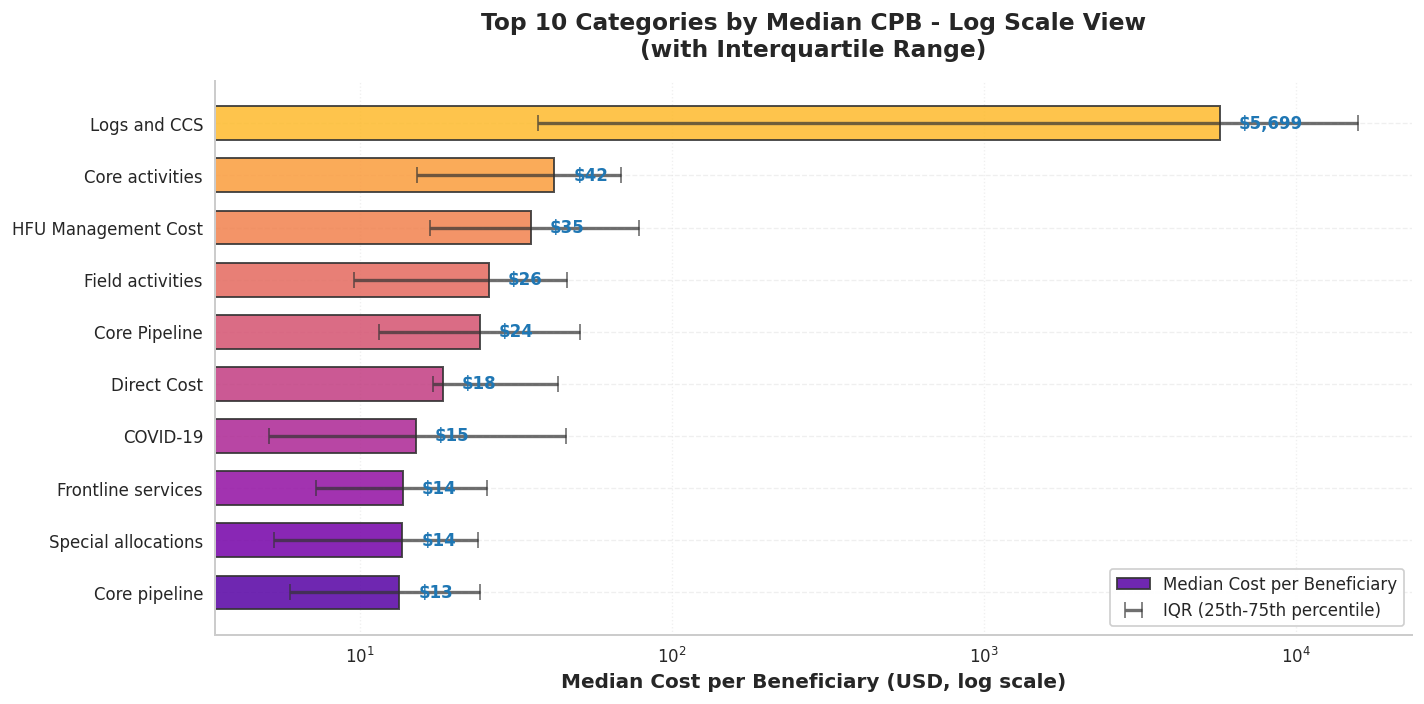

In [9]:
if GROUP_COL:
    stats = (
        cbpf_flagged
        .groupby(GROUP_COL)['cost_per_beneficiary']
        .agg(
            median='median',
            count='count',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        )
        .reset_index()
    )
    stats['iqr_low'] = stats['median'] - stats['q1']
    stats['iqr_high'] = stats['q3'] - stats['median']

    # Keep Top 10 by median, sort ascending for nice display
    stats = stats.sort_values('median', ascending=False).head(10)
    stats = stats.sort_values('median', ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = np.arange(len(stats))

    # Apply Plasma gradient for log-scale visualization
    colors_plasma = plt.cm.plasma(np.linspace(0.15, 0.85, len(stats)))

    # Create bars with gradient
    bars = ax.barh(
        y_pos,
        stats['median'],
        color=colors_plasma,
        alpha=0.85,
        edgecolor='#333333',
        linewidth=1.2,
        height=0.65,
        label='Median Cost per Beneficiary'
    )

    # IQR error bars with enhanced styling
    ax.errorbar(
        stats['median'],
        y_pos,
        xerr=[stats['iqr_low'], stats['iqr_high']],
        fmt='none',
        ecolor='#333333',
        elinewidth=2.0,
        capsize=5,
        alpha=0.7,
        label='IQR (25th-75th percentile)',
        zorder=2
    )

    # Value labels with currency formatting
    for i, v in enumerate(stats['median']):
        ax.text(
            v * 1.15,
            i,
            f'${v:,.0f}',
            va='center',
            fontsize=10,
            fontweight='bold',
            color=COLORS['primary']
        )

    # Format axes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[GROUP_COL].astype(str), fontsize=10)
    ax.set_xlabel('Median Cost per Beneficiary (USD, log scale)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Top 10 Categories by Median CPB - Log Scale View\n(with Interquartile Range)',
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    # LOG SCALE for better visualization of wide ranges
    ax.set_xscale('log')

    # Enhanced grid and styling
    ax.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(loc='lower right', framealpha=0.95, fontsize=10, edgecolor='#cccccc')

    plt.tight_layout()
    plt.show()


In [10]:
# UN Efficiency Review Framework

# Paramters
COST_COL = "cost_spent"
BEN_COL = "beneficiaries_used"
CLUSTER_COL = GROUP_COL
IQR_K = 1.5

def un_efficiency_review_framework(df,
                                   cluster_col,
                                   cost_col=COST_COL,
                                   beneficiary_col=BEN_COL,
                                   iqr_k=IQR_K):
    """Standardized framework to flag outliers within humanitarian clusters."""

    data = df.copy()
    data["cost_per_beneficiary"] = data[cost_col] / data[beneficiary_col]
    data["log_cpb"] = np.log10(data["cost_per_beneficiary"])

    def flag_cluster_outliers(g):
        q1 = g["log_cpb"].quantile(0.25)
        q3 = g["log_cpb"].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_k * iqr
        upper = q3 + iqr_k * iqr
        g = g.copy()
        g["outlier_flag"] = (g["log_cpb"] < lower) | (g["log_cpb"] > upper)
        return g

    reviewed = (
        data.groupby(cluster_col, group_keys=False)
            .apply(flag_cluster_outliers)
    )
    return reviewed

review_results = un_efficiency_review_framework(cbpf, cluster_col=CLUSTER_COL)

cluster_summary = (
    review_results.groupby(CLUSTER_COL)
    .agg(
        projects=("ProjectTitle", "count"),
        total_budget=(COST_COL, "sum"),
        total_beneficiaries=(BEN_COL, "sum"),
        median_cpb=("cost_per_beneficiary", "median"),
        outlier_rate=("outlier_flag", "mean")
    )
    .reset_index()
    .sort_values("outlier_rate", ascending=False)
)

# Rename columns for readability
pretty = cluster_summary.rename(columns={
    CLUSTER_COL: "Allocation Type / Cluster",
    "projects": "Projects",
    "total_budget": "Total Budget (USD)",
    "total_beneficiaries": "Total Beneficiaries",
    "median_cpb": "Median Cost per Beneficiary (USD)",
    "outlier_rate": "Outlier Rate"
})

# Build a styled DataFrame
styled = (
    pretty.style
    .hide(axis="index")
    .set_caption("STANDARDIZED UN EFFICIENCY FRAMEWORK – CLUSTER SUMMARY")
    .set_table_styles([
        # caption
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px 0 4px 0")
            ],
        },
        # overall table
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-family", "Arial, sans-serif"),
                ("font-size", "12px"),
                ("width", "100%")
            ],
        },
        # header
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f4e79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px"),
                ("border-bottom", "1px solid #CCCCCC")
            ],
        },
        # data cells
        {
            "selector": "td",
            "props": [
                ("padding", "5px 6px"),
                ("color", "black"),
                ("border-bottom", "1px solid #EEEEEE")
            ],
        },
    ])
    .format({
        "Projects": "{:,.0f}",
        "Total Budget (USD)": "${:,.0f}",
        "Total Beneficiaries": "{:,.0f}",
        "Median Cost per Beneficiary (USD)": "${:,.2f}",
        "Outlier Rate": "{:.2%}",
    })
    # zebra striping
    .apply(
        lambda s: [
            "background-color: #f7fbff" if i % 2 == 0 else "background-color: white"
            for i in range(len(s))
        ],
        axis=0
    )
    # highlight high outlier rates from green (low) to red (high)
    .background_gradient(
        subset=["Outlier Rate"],
        cmap="RdYlGn_r"  # reversed so high = red
    )
    # align text
    .set_properties(
        subset=["Allocation Type / Cluster"],
        **{"text-align": "left"}
    )
    .set_properties(
        subset=[
            "Projects",
            "Total Budget (USD)",
            "Total Beneficiaries",
            "Median Cost per Beneficiary (USD)",
            "Outlier Rate",
        ],
        **{"text-align": "right"}
    )
)

display(styled)

Allocation Type / Cluster,Projects,Total Budget (USD),Total Beneficiaries,Median Cost per Beneficiary (USD),Outlier Rate
Core pipelines,40,"$15,707,647","2,087,645",$9.84,12.50%
Core Pipeline,55,"$40,185,638","6,752,333",$24.20,10.91%
HFU Management Cost,307,"$204,518,404","10,503,506",$35.38,8.79%
Direct Cost,13,"$5,990,613","273,988",$18.41,7.69%
Special allocations,50,"$19,424,171","6,311,692",$13.68,4.00%
Core activities,106,"$87,287,653","22,640,805",$42.01,2.83%
Field activities,173,"$96,701,514","6,890,550",$25.95,2.31%
Frontline services,"1,141","$399,539,924","49,843,526",$13.71,2.28%
COVID-19,203,"$110,641,137","22,557,122",$15.08,1.48%
Core pipeline,35,"$47,558,041","4,784,907",$13.39,0.00%


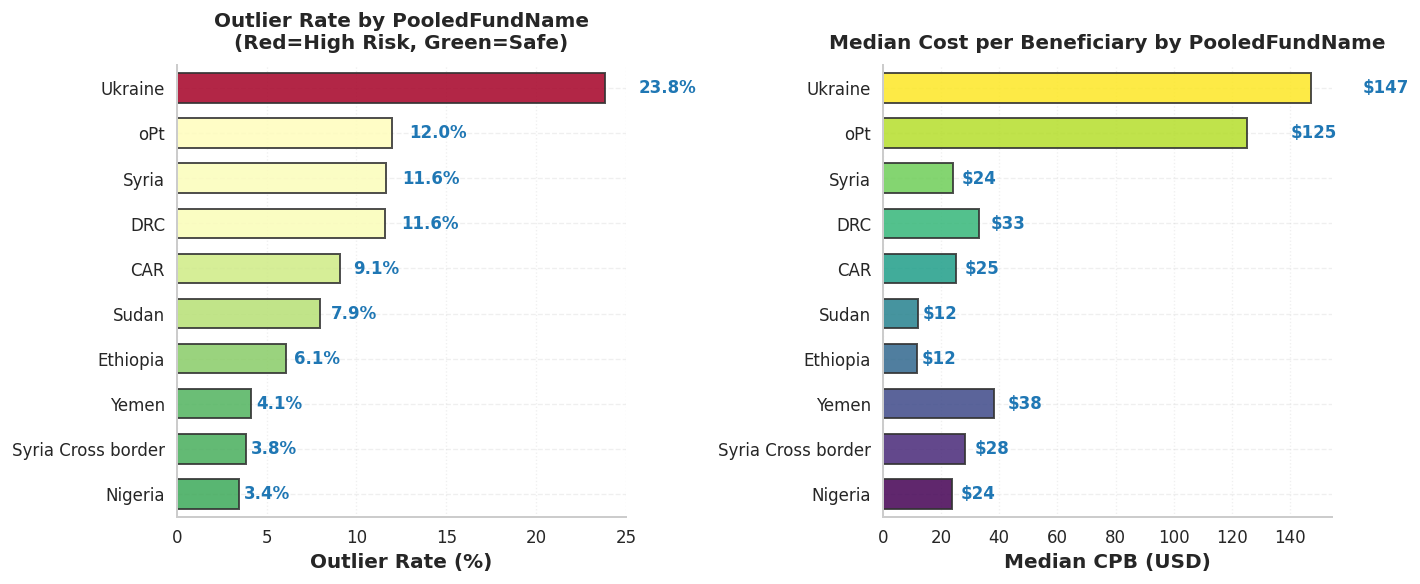

In [11]:
# Outlier Rate by Region

GEO_KEY, GEO_MODE = None, None
for c in ["countryName", "CountryName", "PooledFundName", "regionName"]:
    if c in cbpf_flagged.columns:
        GEO_KEY = c
        break

if GEO_KEY:
    MIN_PROJECTS = 20
    TOP_N = 10

    regional_summary = (
        cbpf_flagged
        .groupby(GEO_KEY)
        .agg(
            projects=("cost_per_beneficiary", "count"),
            median_cpb=("cost_per_beneficiary", "median"),
            outlier_rate=("is_outlier", "mean"),
        )
        .reset_index()
    )

    regional_stable = regional_summary[regional_summary["projects"] >= MIN_PROJECTS].copy()
    top_regions = (
        regional_stable
        .sort_values("outlier_rate", ascending=False)
        .head(TOP_N)
        .sort_values("outlier_rate", ascending=True)
        .reset_index(drop=True)
    )

    # Create two side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    y_pos = np.arange(len(top_regions))

    # Outlier rate
    outlier_norm = top_regions['outlier_rate'] / top_regions['outlier_rate'].max()
    colors_rdylgn = plt.cm.RdYlGn_r(outlier_norm)

    ax1.barh(y_pos, top_regions['outlier_rate'] * 100,
             color=colors_rdylgn, alpha=0.85,
             edgecolor='#333333', linewidth=1.2, height=0.65)

    for i, v in enumerate(top_regions['outlier_rate'] * 100):
        ax1.text(v * 1.08, i, f'{v:.1f}%',
                 va='center', fontsize=10, fontweight='bold',
                 color=COLORS['primary'])

    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(top_regions[GEO_KEY].astype(str), fontsize=10)
    ax1.set_xlabel('Outlier Rate (%)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Outlier Rate by {GEO_KEY}\n(Red=High Risk, Green=Safe)',
                  fontsize=12, fontweight='bold', pad=10)
    ax1.grid(axis='x', alpha=0.3, linestyle=':')
    ax1.set_axisbelow(True)

    # Median value
    colors_viridis = plt.cm.viridis(np.linspace(0, 1, len(top_regions)))

    ax2.barh(y_pos, top_regions['median_cpb'],
             color=colors_viridis, alpha=0.85,
             edgecolor='#333333', linewidth=1.2, height=0.65)

    for i, v in enumerate(top_regions['median_cpb']):
        ax2.text(v * 1.12, i, f'${v:,.0f}',
                 va='center', fontsize=10, fontweight='bold',
                 color=COLORS['primary'])

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(top_regions[GEO_KEY].astype(str), fontsize=10)
    ax2.set_xlabel('Median CPB (USD)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Median Cost per Beneficiary by {GEO_KEY}',
                  fontsize=12, fontweight='bold', pad=10)
    ax2.grid(axis='x', alpha=0.3, linestyle=':')
    ax2.set_axisbelow(True)

    # Synchronized y-axes
    ax1.set_ylim(-0.5, len(top_regions) - 0.5)
    ax2.set_ylim(-0.5, len(top_regions) - 0.5)

    # Remove right spines
    ax1.spines['right'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [12]:
# CERF Donor Contributions Analysis

dc = donor_contributions.copy()

# Find the donor column dynamically
DONOR_COL = None
for c in ["donor", "Donor", "donorName", "DonorName"]:
    if c in dc.columns:
        DONOR_COL = c
        print(f"Identified donor column: '{DONOR_COL}'")
        break


if DONOR_COL and "donorreceived" in dc.columns:
    donor_all = (
        dc.dropna(subset=[DONOR_COL, "donorreceived"])
        .groupby(DONOR_COL, as_index=False)
        .agg(
            total_received=("donorreceived", "sum"),
            n_records=("donorreceived", "count")
        )
        .copy()
    )

    # Map donor names -> ISO3
    try:
        import pycountry
    except ImportError:
        %pip install pycountry
        import pycountry

    def name_to_iso3(name: str):
        if pd.isna(name):
            return None
        n = str(name).strip()

        fixes = {
            "United States": "USA",
            "United States of America": "USA",
            "Russia": "RUS",
            "Viet Nam": "VNM",
            "Iran": "IRN",
            "Bolivia": "BOL",
            "Venezuela": "VEN",
            "Congo": "COG",
            "Democratic Republic of the Congo": "COD",
            "Tanzania": "TZA",
            "Syria": "SYR",
            "Lao People's Democratic Republic": "LAO",
            "Korea, Republic of": "KOR",
            "Korea, Democratic People's Republic of": "PRK",
            "Côte d’Ivoire": "CIV",
            "Cote d'Ivoire": "CIV",
            "Czechia": "CZE",
            "United Kingdom": "GBR",
        }
        if n in fixes:
            return fixes[n]

        try:
            return pycountry.countries.lookup(n).alpha_3
        except Exception:
            return None

    donor_all["iso3"] = donor_all[DONOR_COL].apply(name_to_iso3)

    mapped_rate = donor_all["iso3"].notna().mean()
    print(f"ISO3 mapping success: {mapped_rate:.1%} ({donor_all['iso3'].notna().sum()} / {len(donor_all)})")

    unmapped = donor_all[donor_all["iso3"].isna()].sort_values("total_received", ascending=False).head(15)
    if len(unmapped) > 0:
        print("Top unmapped donor names (not countries / naming mismatch):")
        display(unmapped)

    # Plot choropleth
    try:
        import plotly.express as px
    except ImportError:
        %pip install plotly
        import plotly.express as px

    donor_all["log_total_received"] = np.log10(donor_all["total_received"].clip(lower=1))

    fig = px.choropleth(
        donor_all.dropna(subset=["iso3"]),
        locations="iso3",
        locationmode="ISO-3",
        color="log_total_received",
        hover_name=DONOR_COL,
        hover_data={
            "total_received": ":,.2f",
            "n_records": True,
            "log_total_received": ":.2f",
        },
        title="CERF Donor Contributions (Total Received) — All Countries (log10 scale)"
    )
    fig.update_layout(margin=dict(l=20, r=20, t=60, b=20))
    fig.show()
else:
    print("Skipping donor world map (missing donor/donorreceived columns).")

Identified donor column: 'donor'
ISO3 mapping success: 67.9% (133 / 196)
Top unmapped donor names (not countries / naming mismatch):


,donor,total_received,n_records,iso3
95,Korea,"111,823,817.29",25,None
18,Belgian Government of Flanders,"9,491,325.00",18,None
142,Qatar Charity,"9,000,000.00",4,None
174,Turkey,"7,799,630.00",32,None
140,Private donations through UN Foundation (under...,"2,970,780.75",35,None
35,Catalan Agency for Development Cooperation,"2,888,381.05",9,None
163,"Stripe, Ireland","1,808,241.23",6,None
17,Basque Agency for Development Cooperation,"1,599,098.04",9,None
30,ByteDance/TikTok,"1,000,000.00",1,None
115,Mohamed Fathi Ahmed Ibrahim,"1,000,000.00",1,None


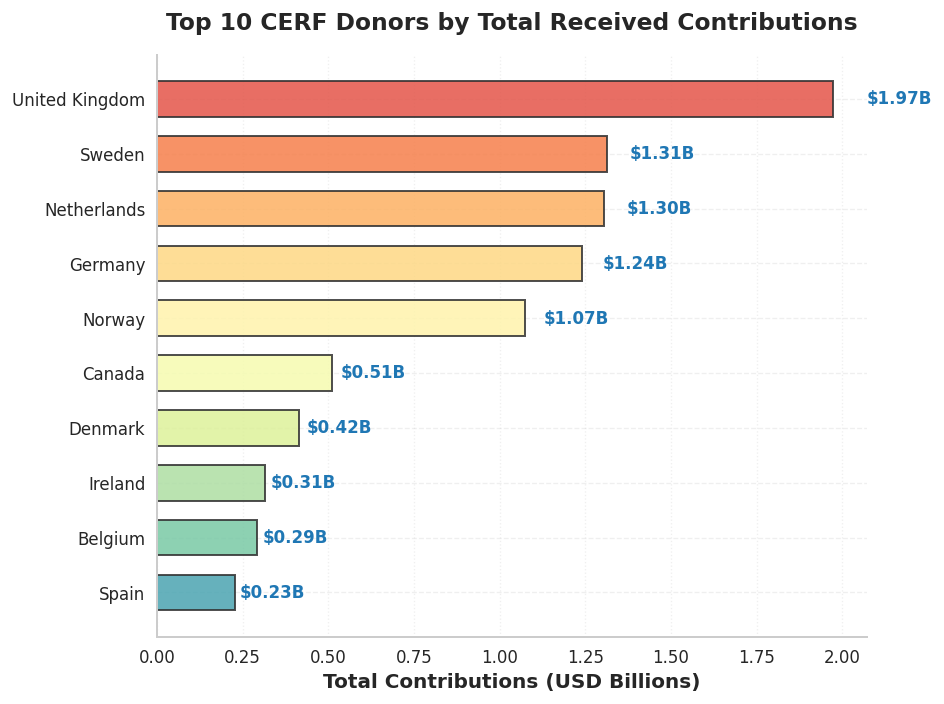

In [13]:
dc = donor_contributions.copy()

# Convert to numeric
for col in ["donorcommitment", "donorpledge", "donorreceived", "donorwriteoff"]:
    if col in dc.columns:
        dc[col] = pd.to_numeric(dc[col], errors="coerce")

DONOR_COL = "donor" if "donor" in dc.columns else None

if DONOR_COL and "donorreceived" in dc.columns:
    donor_funding = (
        dc.dropna(subset=[DONOR_COL, "donorreceived"])
        .groupby(DONOR_COL, as_index=False)
        .agg({
            "donorreceived": ["sum", "count"]
        })
        .rename(columns={"donorreceived": "Donor"})
        .sort_values(("Donor", "sum"), ascending=False)
        .head(10)
        .copy()
    )

    # Flatten column names
    donor_funding.columns = [DONOR_COL, 'total', 'count']

    fig, ax = plt.subplots(figsize=(8, 6))
    y_pos = np.arange(len(donor_funding))

    # Apply Spectral gradient colors
    colors_spectral = plt.cm.Spectral(np.linspace(0.15, 0.85, len(donor_funding)))
    amounts_display = donor_funding['total'] / 1e9

    bars = ax.barh(y_pos, amounts_display,
                   color=colors_spectral, alpha=0.85,
                   edgecolor='#333333', linewidth=1.2, height=0.65)

    # Value labels in billions
    for i, v in enumerate(amounts_display):
        ax.text(v * 1.05, i, f'${v:.2f}B',
                va='center', fontsize=10, fontweight='bold',
                color=COLORS['primary'])

    ax.set_yticks(y_pos)
    ax.set_yticklabels(donor_funding[DONOR_COL].astype(str), fontsize=10)
    ax.set_xlabel('Total Contributions (USD Billions)', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 CERF Donors by Total Received Contributions',
                 fontsize=14, fontweight='bold', pad=15)

    ax.grid(axis='x', alpha=0.3, linestyle=':')
    ax.set_axisbelow(True)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

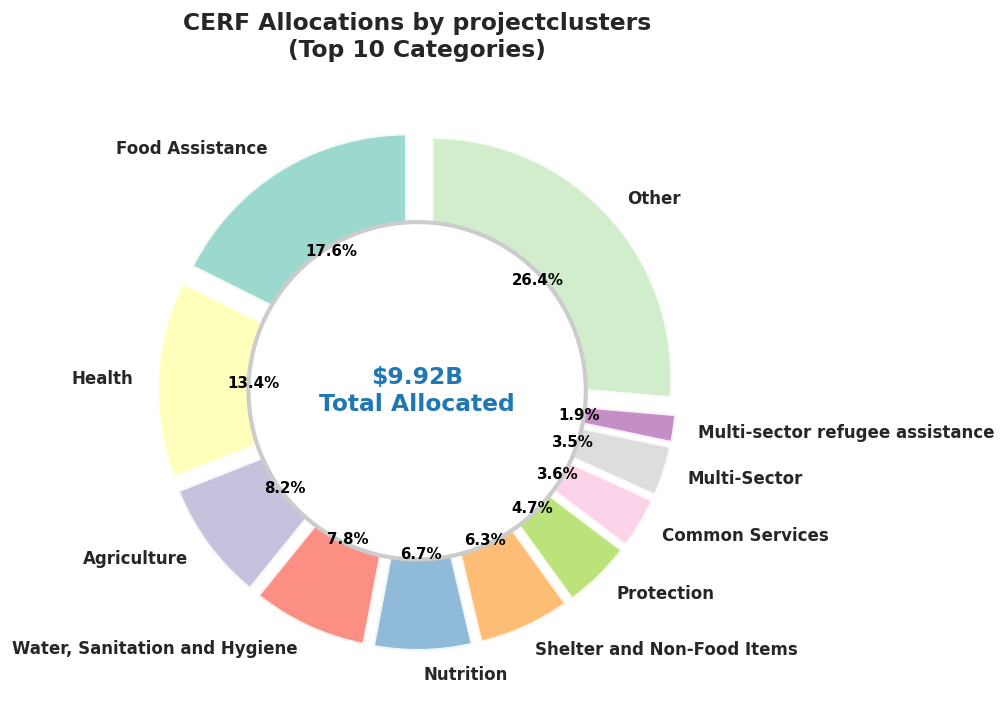

In [14]:

da = donor_allocations.copy()
da.columns = da.columns.str.strip()

def parse_currency(val):
    if pd.isna(val): return np.nan
    cleaned = re.sub(r"[^\d.]", "", str(val).strip())
    return float(cleaned) if cleaned else np.nan

if "totalAmountApproved" in da.columns:
    da["totalAmountApproved"] = da["totalAmountApproved"].apply(parse_currency)

lens_candidates = ["projectclusters", "projectsectors", "emergencyTypeName",
                   "regionName", "agencyName", "countryName"]
LENS_COL = next((c for c in lens_candidates if c in da.columns), None)

if LENS_COL and "totalAmountApproved" in da.columns:
    cerf_alloc = (
        da.dropna(subset=[LENS_COL, "totalAmountApproved"])
        .groupby(LENS_COL, as_index=False)
        .agg({"totalAmountApproved": "sum"})
        .rename(columns={"totalAmountApproved": "total"})
        .sort_values("total", ascending=False)
        .copy()
    )

    top_alloc = cerf_alloc.head(10).copy()

    if len(cerf_alloc) > 10:
        other = pd.DataFrame({
            LENS_COL: ["Other"],
            "total": [cerf_alloc.iloc[10:]["total"].sum()]
        })
        top_alloc = pd.concat([top_alloc, other], ignore_index=True)

    fig, ax = plt.subplots(figsize=(8, 6))

    colors_set3 = sns.color_palette("Set3", len(top_alloc))
    explode = [0.08] * len(top_alloc)

    wedges, texts, autotexts = ax.pie(
        top_alloc["total"],
        labels=top_alloc[LENS_COL].astype(str),
        autopct="%1.1f%%",
        colors=colors_set3,
        explode=explode,
        startangle=90,
        textprops={"fontsize": 10, "fontweight": "bold"},
        wedgeprops=dict(edgecolor="white", linewidth=2.5, alpha=0.88)
    )

    for autotext in autotexts:
        autotext.set_color("black")
        autotext.set_fontsize(9)
        autotext.set_fontweight("bold")

    centre_circle = plt.Circle((0, 0), 0.70, fc="white",
                               linewidth=2.5, edgecolor="#cccccc")
    ax.add_artist(centre_circle)

    total_billions = top_alloc["total"].sum() / 1e9
    ax.text(0, 0, f"${total_billions:.2f}B\nTotal Allocated",
            ha="center", va="center",
            fontsize=14, fontweight="bold", color=COLORS["primary"])

    ax.set_title(f"CERF Allocations by {LENS_COL}\n(Top 10 Categories)",
                 fontsize=14, fontweight="bold", pad=20)

    plt.tight_layout()
    plt.show()

else:
    print(f"Could not render chart. LENS_COL={LENS_COL}, "
          f"'totalAmountApproved' found: {'totalAmountApproved' in da.columns}")